# NEOMOD3 sample count x kNN neighbour count — NEO velocity-density maps

**Experimental question.** How do the NEOMOD3 Monte Carlo sample count and the kNN neighbour
count `k` change the smoothness and structure of the NEO velocity-density map?

## Controlled variables

Everything below is held fixed across all eight cases:

| held fixed | value |
|---|---|
| sky center | `dlon+000_lat+00` |
| magnitude bin | `mag24+` (apparent 24 <= mag < 25) |
| epoch / observer geometry | frozen production epoch `2027-08-25T00:00:00` |
| velocity domain | [-5, +5] deg/day in both `v_lambda` and `v_beta` |
| grid spacing | 0.01 deg/day (1001 x 1001) |
| NEO source | direct NEOMOD3 draws only |
| density estimator | Bayesian kNN (sealed module) |
| Gaussian smoothing | **OFF** |
| support masking / post-processing | none |
| non-NEO densities for P(NEO) | fixed production MBA / TNO / Trojan maps, byte-identical in all cases |
| `n_d0_grid` quadrature resolution | 8000 nodes, identical in all cases |

## Varied variables

|  | k=10 | k=25 | k=50 | k=100 |
|---|---|---|---|---|
| **BASE** source count | x | x | x | x |
| **HIGH** source count | x | x | x | x |

`HIGH` is **nested**: `HIGH = all BASE rows + additional independent NEOMOD3 draws` with recorded,
non-overlapping seeds. Both cases represent the same modelled physical NEO abundance — raising the
draw budget raises `n_draws`, and therefore `effective_factor = n_draws / total_weight`, by the same
factor, so the total physical weight is preserved. That is checked numerically in section 2.

### A note on the quadrature resolution

The sealed posterior integrand is `p(d0) ~ d0^-k(k+1) exp(-S/d0^2)` with `S = sum_j d_j^2`, whose
peak narrows sharply as `k` grows. Against the exact closed form
`n0 = (k(k+1)/2 - 1/2) / (pi S)`, the production default of 400 quadrature nodes is converged at
k=10 (7e-16) but **not** at k=50 (2.6e-04) or k=100 (1.1e-02). Left at 400, that numerical error
would grow with `k` and appear as a structural change in exactly this comparison. All eight cases
therefore use 8000 nodes, which is converged to <= 4e-15 at every `k`.

In [1]:
import json, hashlib
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, TwoSlopeNorm

W = Path("/mmfs1/gscratch/dirac/ds2004/sorcha")
OUT = W/"outputs"/"more_neomod_samples_knn"
SRCS = ("BASE","HIGH"); KS = (10,25,50,100)
dens = {(s,k): np.load(OUT/"maps"/f"density_{s}_k{k:03d}.npz", allow_pickle=True)
        for s in SRCS for k in KS}
post = {(s,k): np.load(OUT/"maps"/f"posterior_{s}_k{k:03d}.npz", allow_pickle=True)
        for s in SRCS for k in KS}
prov = json.load(open(OUT/"provenance.json"))
z0 = dens[("BASE",10)]
xg = np.asarray(z0["x_grid"], float); yg = np.asarray(z0["y_grid"], float)
print(f"grid: {len(xg)} x {len(yg)}   x [{xg.min():.2f}, {xg.max():.2f}]   step {xg[1]-xg[0]:.4f}")
# central +-1 deg/day window used for display
i0, i1 = int(np.searchsorted(xg,-1.0)), int(np.searchsorted(xg,1.0))+1
j0, j1 = int(np.searchsorted(yg,-1.0)), int(np.searchsorted(yg,1.0))+1
EXT = [xg[i0], xg[i1-1], yg[j0], yg[j1-1]]
cen = lambda a: np.asarray(a, float)[j0:j1, i0:i1]
print(f"display window: x[{i0}:{i1}] y[{j0}:{j1}] -> {i1-i0} x {j1-j0} px, extent {EXT}")

grid: 1001 x 1001   x [-5.00, 5.00]   step 0.0100
display window: x[401:602] y[401:602] -> 201 x 201 px, extent [np.float64(-0.9900000000000855), np.float64(1.009999999999872), np.float64(-0.9900000000000855), np.float64(1.009999999999872)]


## 1. Controlled-variable assertions

Every case must share grid, epoch, center, magnitude bin, smoothing flag and quadrature
resolution, and each row must share one source hash.

In [2]:
rows=[]
for s in SRCS:
    for k in KS:
        z=dens[(s,k)]
        rows.append(dict(source=s, k=int(z["k"]), n_source_rows=int(z["n_source_rows"]),
            total_physical_weight=float(z["total_physical_weight"]),
            effective_factor=float(z["effective_factor"]), n_draws=int(z["n_draws"]),
            source_sha256=str(z["source_sha256"]), gaussian_smoothing=bool(z["gaussian_smoothing"]),
            n_d0_grid=int(z["n_d0_grid"]), estimator_k_observed=int(z["estimator_k_observed"]),
            epoch=str(z["epoch"]), center=str(z["center_label"]), magbin=str(z["magnitude_bin"]),
            grid_step=float(z["grid_step"]), nx=len(np.asarray(z["x_grid"]))))
t=pd.DataFrame(rows)

def chk(name, cond):
    print(f"  {'PASS' if cond else 'FAIL'}  {name}"); assert cond, name

print("controlled-variable assertions")
chk("all 8 cases present", len(t)==8)
chk("requested k reached the estimator in every case", (t.k==t.estimator_k_observed).all())
chk("Gaussian smoothing False everywhere", (~t.gaussian_smoothing).all())
chk("identical n_d0_grid everywhere", t.n_d0_grid.nunique()==1)
chk("identical epoch / center / magnitude bin", t.epoch.nunique()==1 and t.center.nunique()==1
                                                 and t.magbin.nunique()==1)
chk("identical grid (step and size)", t.grid_step.nunique()==1 and t.nx.nunique()==1)
for s in SRCS:
    chk(f"all four k in row {s} share one source hash", t[t.source==s].source_sha256.nunique()==1)
chk("BASE and HIGH are different sources", t.source_sha256.nunique()==2)
xs=[np.asarray(dens[(s,k)]["x_grid"],float) for s in SRCS for k in KS]
ys=[np.asarray(dens[(s,k)]["y_grid"],float) for s in SRCS for k in KS]
chk("x_grid byte-identical across cases", all(np.array_equal(a,xs[0]) for a in xs))
chk("y_grid byte-identical across cases", all(np.array_equal(a,ys[0]) for a in ys))
pp=json.load(open(OUT/"posterior_provenance.json"))
chk("identical non-NEO arrays across all 8 cases", pp["identical_nonneo_arrays_across_all_cases"])

controlled-variable assertions
  PASS  all 8 cases present
  PASS  requested k reached the estimator in every case
  PASS  Gaussian smoothing False everywhere
  PASS  identical n_d0_grid everywhere
  PASS  identical epoch / center / magnitude bin
  PASS  identical grid (step and size)
  PASS  all four k in row BASE share one source hash
  PASS  all four k in row HIGH share one source hash
  PASS  BASE and HIGH are different sources
  PASS  x_grid byte-identical across cases
  PASS  y_grid byte-identical across cases
  PASS  identical non-NEO arrays across all 8 cases


## 2. Source counts, physical weights, seeds and hashes

In [3]:
man=json.load(open(OUT/"high_draw_manifest.json"))
b=t[t.source=="BASE"].iloc[0]; h=t[t.source=="HIGH"].iloc[0]
print("SOURCE COUNTS")
print(f"  BASE selected rows : {b.n_source_rows:,}")
print(f"  HIGH selected rows : {h.n_source_rows:,}   (= BASE {man['n_rows_base']:,} + "
      f"new {man['n_rows_extra']:,})")
print(f"  HIGH / BASE        : {h.n_source_rows/b.n_source_rows:.4f}x")
print()
print("PHYSICAL NORMALISATION   (weight per row = 1 / effective_factor)")
print(f"  BASE  n_draws {b.n_draws:>14,}   effective_factor {b.effective_factor:>10.6f}")
print(f"  HIGH  n_draws {h.n_draws:>14,}   effective_factor {h.effective_factor:>10.6f}")
print(f"  total physical weight  BASE {b.total_physical_weight:,.6f}")
print(f"  total physical weight  HIGH {h.total_physical_weight:,.6f}")
rel=abs(h.total_physical_weight-b.total_physical_weight)/b.total_physical_weight
print(f"  relative difference    {rel:.4e}   (tolerance {prov['weight_tolerance']:.0e})")
chk("BASE and HIGH physical weight totals agree", rel < prov["weight_tolerance"])
print()
print("SEEDS")
print(f"  new-draw seeds        : {man['seed_base']:,} + 0..{man['n_shards']-1}  "
      f"({man['n_shards']} shards x {man['draws_per_shard']:,} draws = "
      f"{man['n_extra_draws_total']:,})")
print(f"  original cache seeds  : {man['original_cache_seed_range'][0]}.."
      f"{man['original_cache_seed_range'][1]}")
print(f"  overlap               : {man['seed_overlap_with_original_cache']}")
print(f"  duplicate orbital records in HIGH : {man['duplicate_orbital_records']}")
print(f"  HIGH nested on BASE               : {man['nested']}")
print()
print("HASHES")
print(f"  source_base.parquet : {b.source_sha256}")
print(f"  source_high.parquet : {h.source_sha256}")
for p,s in pp["fixed_nonneo_sha256"].items(): print(f"  fixed {p:8s}    : {s}")
print(f"  sealed VDP module   : {prov['sealed_module_sha256']}")
print(f"  code commit         : {prov['code_commit']}")

SOURCE COUNTS
  BASE selected rows : 27,781
  HIGH selected rows : 207,059   (= BASE 27,781 + new 179,278)
  HIGH / BASE        : 7.4533x

PHYSICAL NORMALISATION   (weight per row = 1 / effective_factor)
  BASE  n_draws    100,000,000   effective_factor   8.746673
  HIGH  n_draws    740,000,000   effective_factor  64.725384
  total physical weight  BASE 3,176.178934
  total physical weight  HIGH 3,199.038590
  relative difference    7.1972e-03   (tolerance 2e-02)
  PASS  BASE and HIGH physical weight totals agree

SEEDS
  new-draw seeds        : 1,000,000 + 0..319  (320 shards x 2,000,000 draws = 640,000,000)
  original cache seeds  : 42..141
  overlap               : False
  duplicate orbital records in HIGH : 0
  HIGH nested on BASE               : True

HASHES
  source_base.parquet : 03dd6e13a3a4896c1d5d478d3490dc4a7ef515f0a407ccb7b74b46631d04801c
  source_high.parquet : 40490b3bc4ffaec122919981396168299c1e84a384dd345c46f8a7adb20fc297
  fixed MBA         : a85c2965191dbc22a9d0c5f645

## 3. NEO density maps — shared logarithmic colour scale

Rows: `BASE` / `HIGH`. Columns: k = 10, 25, 50, 100. Identical axes, one shared colour scale,
central [-1, +1] deg/day window.

shared colour scale: 57.67 .. 4.389e+04  (log)


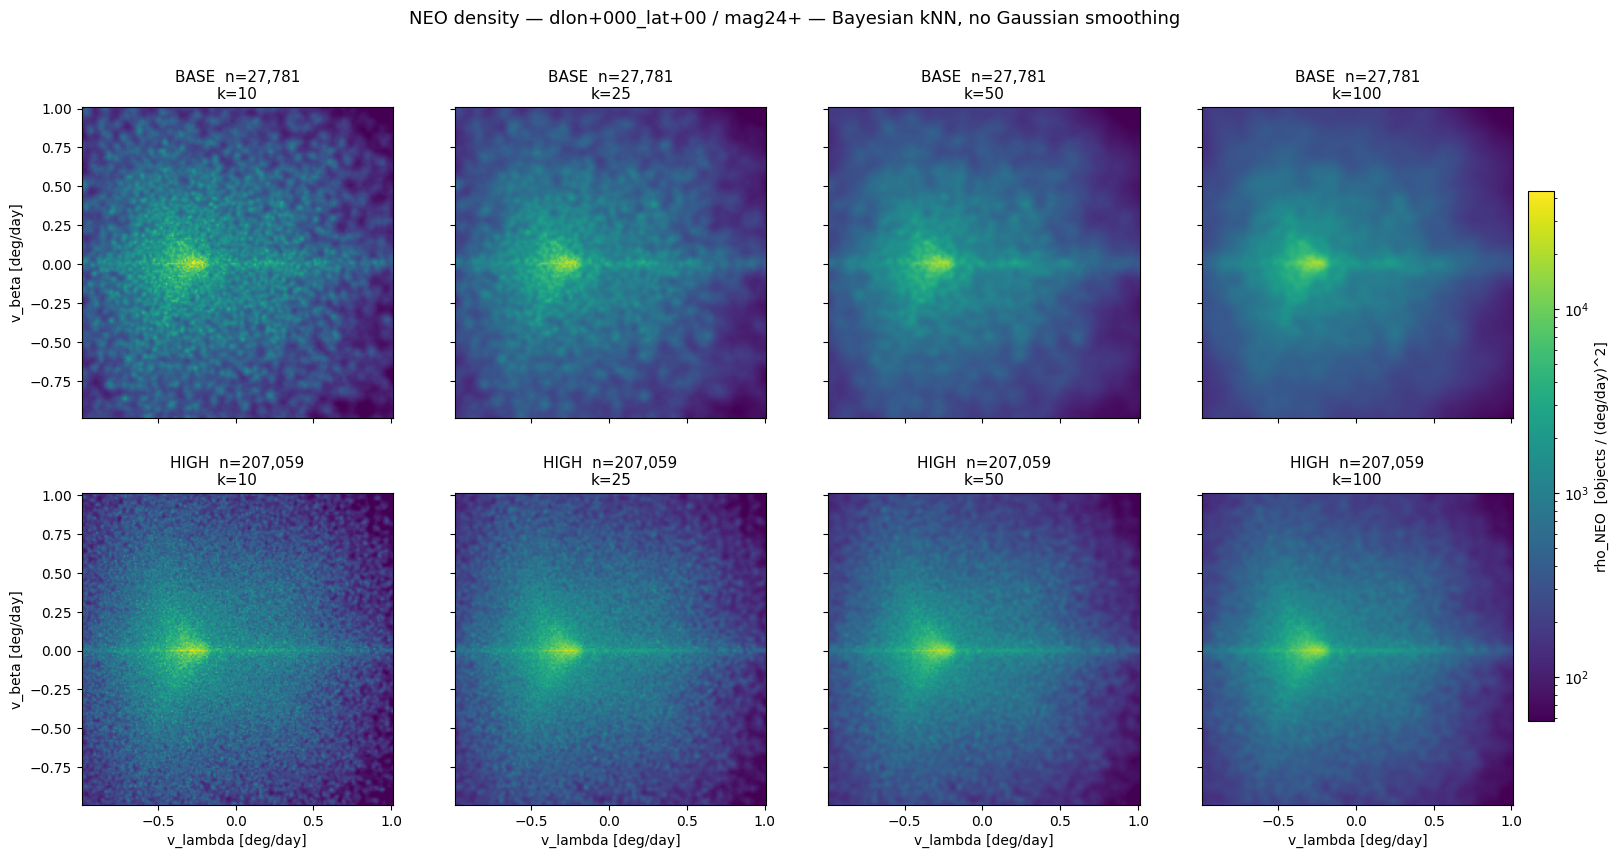

In [4]:
def dmap(s,k): return cen(dens[(s,k)]["density_neo_physical"])
allpos=np.concatenate([dmap(s,k)[np.isfinite(dmap(s,k)) & (dmap(s,k)>0)].ravel()
                       for s in SRCS for k in KS])
VMIN,VMAX=np.percentile(allpos,0.5),allpos.max()
print(f"shared colour scale: {VMIN:.4g} .. {VMAX:.4g}  (log)")
nrm=LogNorm(vmin=VMIN,vmax=VMAX)
fig,ax=plt.subplots(2,4,figsize=(19,9.2),sharex=True,sharey=True)
for r,s in enumerate(SRCS):
    for c,k in enumerate(KS):
        a=ax[r,c]; im=a.imshow(np.ma.masked_invalid(dmap(s,k)),origin="lower",extent=EXT,
                               norm=nrm,cmap="viridis",aspect="equal")
        a.set_title(f"{s}  n={int(dens[(s,k)]['n_source_rows']):,}\nk={k}",fontsize=11)
        if r==1: a.set_xlabel("v_lambda [deg/day]")
        if c==0: a.set_ylabel("v_beta [deg/day]")
fig.colorbar(im,ax=ax,fraction=0.018,pad=0.01,label="rho_NEO  [objects / (deg/day)^2]")
fig.suptitle("NEO density — dlon+000_lat+00 / mag24+ — Bayesian kNN, no Gaussian smoothing",
             fontsize=13)
plt.show()

## 4. The same maps with a fixed-size source-point overlay

The overlay is the identical marker size and alpha in every panel, so the visual density of points
reflects the actual sample count.

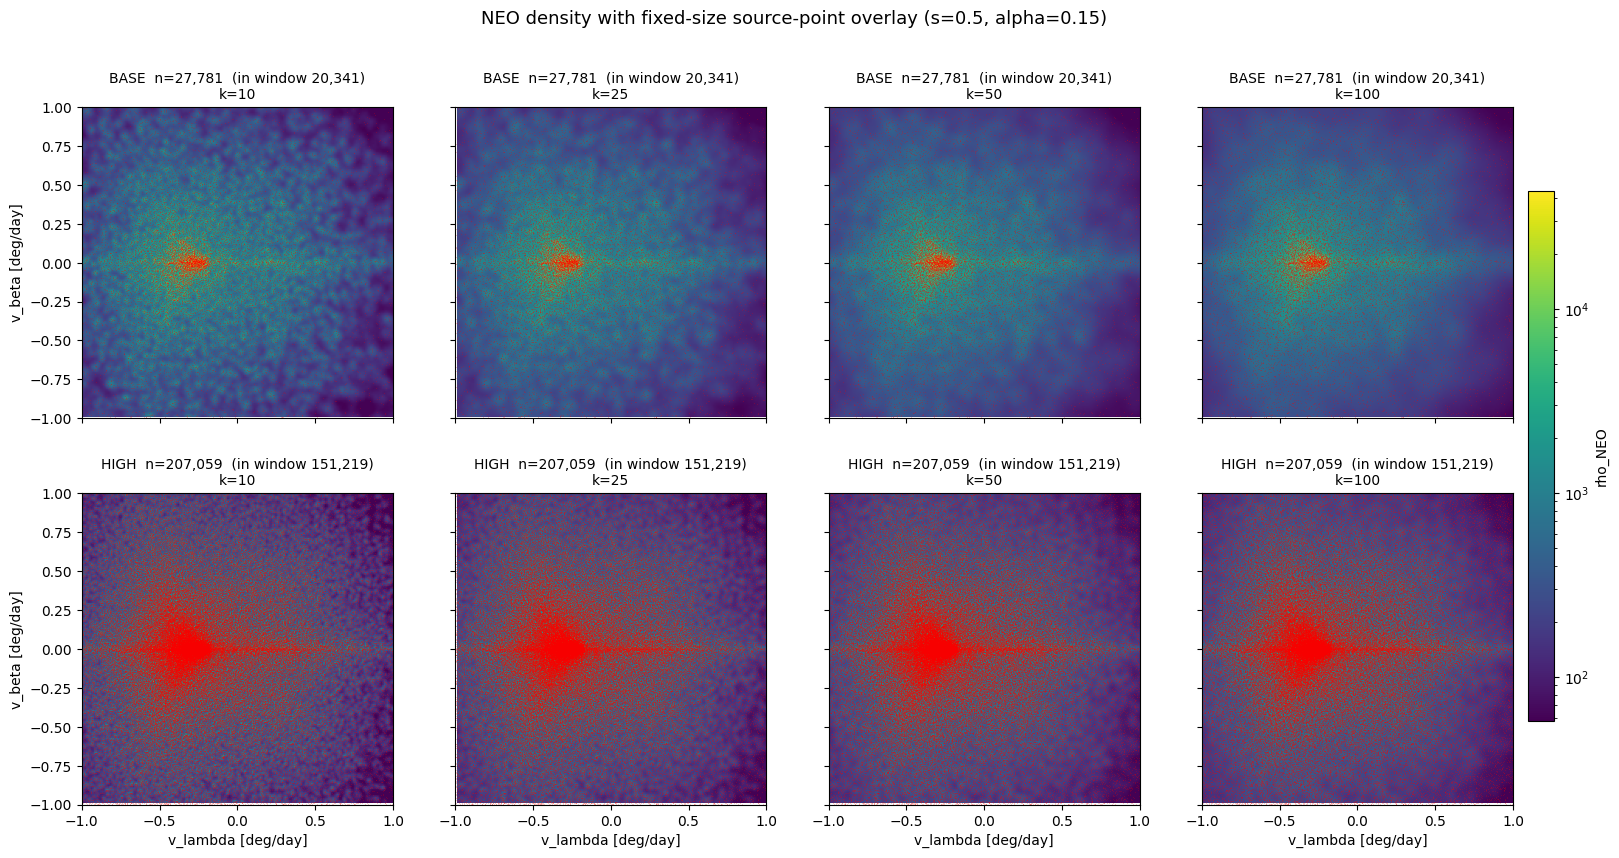

In [5]:
sb=pd.read_parquet(OUT/"source_base.parquet",columns=["vlam","vbeta"])
sh=pd.read_parquet(OUT/"source_high.parquet",columns=["vlam","vbeta"])
PTS={"BASE":sb,"HIGH":sh}
fig,ax=plt.subplots(2,4,figsize=(19,9.2),sharex=True,sharey=True)
for r,s in enumerate(SRCS):
    p=PTS[s]; m=(p.vlam.between(-1,1))&(p.vbeta.between(-1,1))
    for c,k in enumerate(KS):
        a=ax[r,c]; im=a.imshow(np.ma.masked_invalid(dmap(s,k)),origin="lower",extent=EXT,
                               norm=nrm,cmap="viridis",aspect="equal")
        a.scatter(p.vlam[m],p.vbeta[m],s=0.5,c="red",alpha=0.15,linewidths=0)
        a.set_xlim(-1,1); a.set_ylim(-1,1)
        a.set_title(f"{s}  n={int(dens[(s,k)]['n_source_rows']):,}  "
                    f"(in window {int(m.sum()):,})\nk={k}",fontsize=10)
        if r==1: a.set_xlabel("v_lambda [deg/day]")
        if c==0: a.set_ylabel("v_beta [deg/day]")
fig.colorbar(im,ax=ax,fraction=0.018,pad=0.01,label="rho_NEO")
fig.suptitle("NEO density with fixed-size source-point overlay (s=0.5, alpha=0.15)",fontsize=13)
plt.show()

## 5. P(NEO) using the fixed non-NEO densities

    P(NEO) = rho_NEO / (rho_NEO + rho_MBA + rho_TNO + rho_Trojan)

The three non-NEO arrays are byte-identical in all eight cases (hash-checked in section 1), so any
difference between panels comes only from `rho_NEO`. Undefined pixels stay NaN.

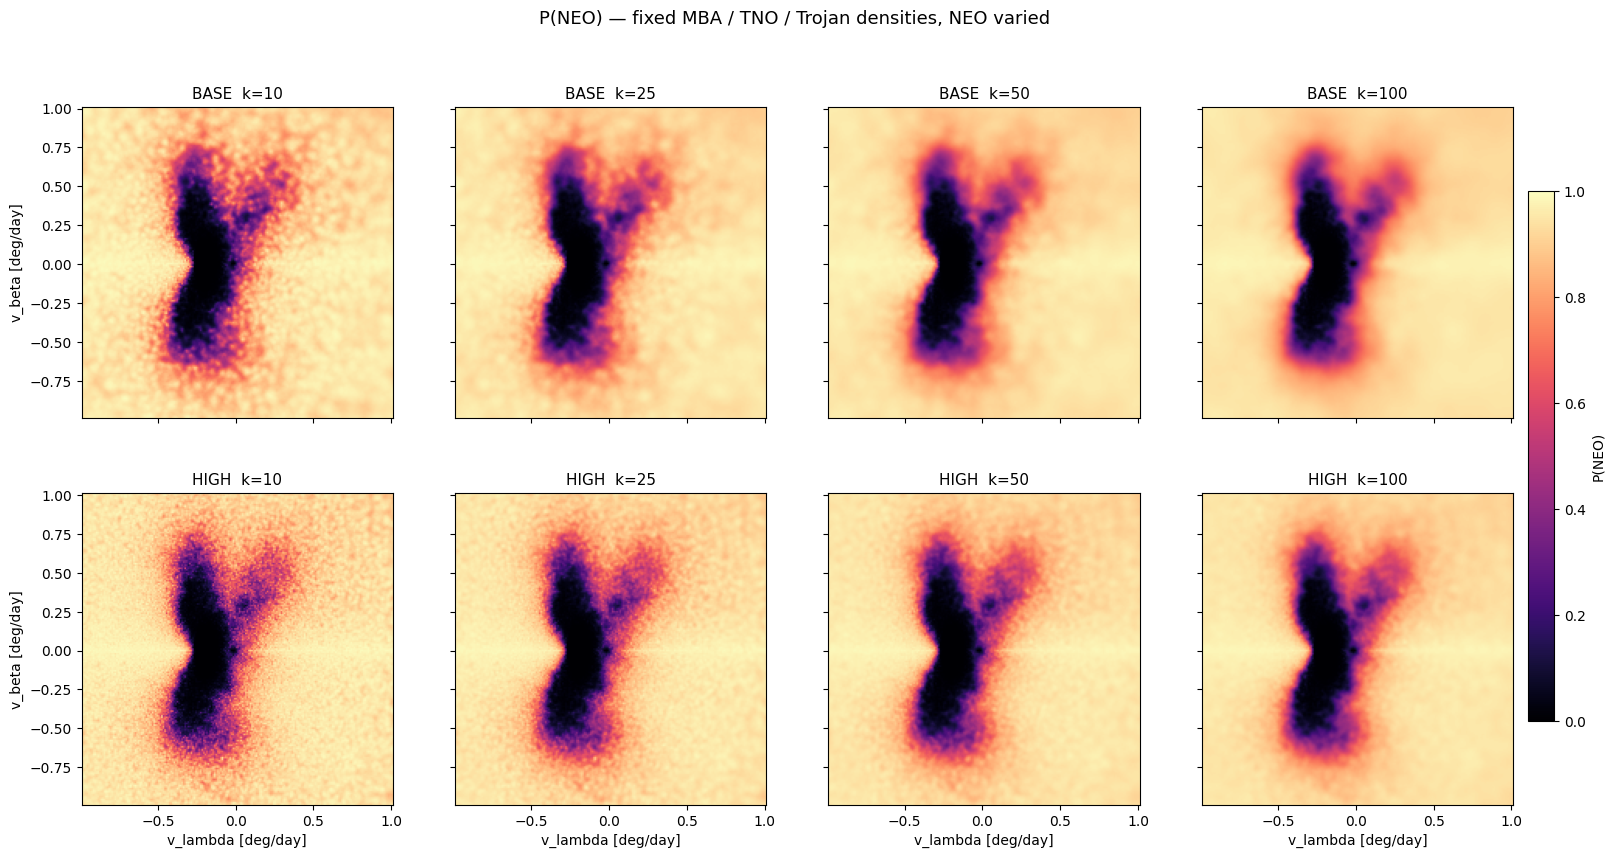

max |sum of four class probabilities - 1| per case (defined pixels only):
  BASE k= 10  3.331e-16   defined 1,002,001  undefined 0
  BASE k= 25  3.331e-16   defined 1,002,001  undefined 0
  BASE k= 50  3.331e-16   defined 1,002,001  undefined 0
  BASE k=100  3.331e-16   defined 1,002,001  undefined 0
  HIGH k= 10  3.331e-16   defined 1,002,001  undefined 0
  HIGH k= 25  3.331e-16   defined 1,002,001  undefined 0
  HIGH k= 50  3.331e-16   defined 1,002,001  undefined 0
  HIGH k=100  3.331e-16   defined 1,002,001  undefined 0


In [6]:
fig,ax=plt.subplots(2,4,figsize=(19,9.2),sharex=True,sharey=True)
for r,s in enumerate(SRCS):
    for c,k in enumerate(KS):
        a=ax[r,c]; P=cen(post[(s,k)]["P_NEO"])
        im=a.imshow(np.ma.masked_invalid(P),origin="lower",extent=EXT,vmin=0,vmax=1,
                    cmap="magma",aspect="equal")
        a.set_title(f"{s}  k={k}",fontsize=11)
        if r==1: a.set_xlabel("v_lambda [deg/day]")
        if c==0: a.set_ylabel("v_beta [deg/day]")
fig.colorbar(im,ax=ax,fraction=0.018,pad=0.01,label="P(NEO)")
fig.suptitle("P(NEO) — fixed MBA / TNO / Trojan densities, NEO varied",fontsize=13)
plt.show()
print("max |sum of four class probabilities - 1| per case (defined pixels only):")
for s in SRCS:
    for k in KS:
        z=post[(s,k)]
        print(f"  {s:4s} k={k:3d}  {float(z['max_abs_sum_deviation']):.3e}   "
              f"defined {int(np.asarray(z['defined']).sum()):,}  "
              f"undefined {int((~np.asarray(z['defined'])).sum()):,}")

## 6. Difference maps relative to BASE, k=10

`log10(rho / rho_BASE_k10)`, symmetric diverging scale. The reference panel is identically zero
by construction.

symmetric colour limit: +/- 0.457 dex  (99.5th percentile of |log10 ratio|)


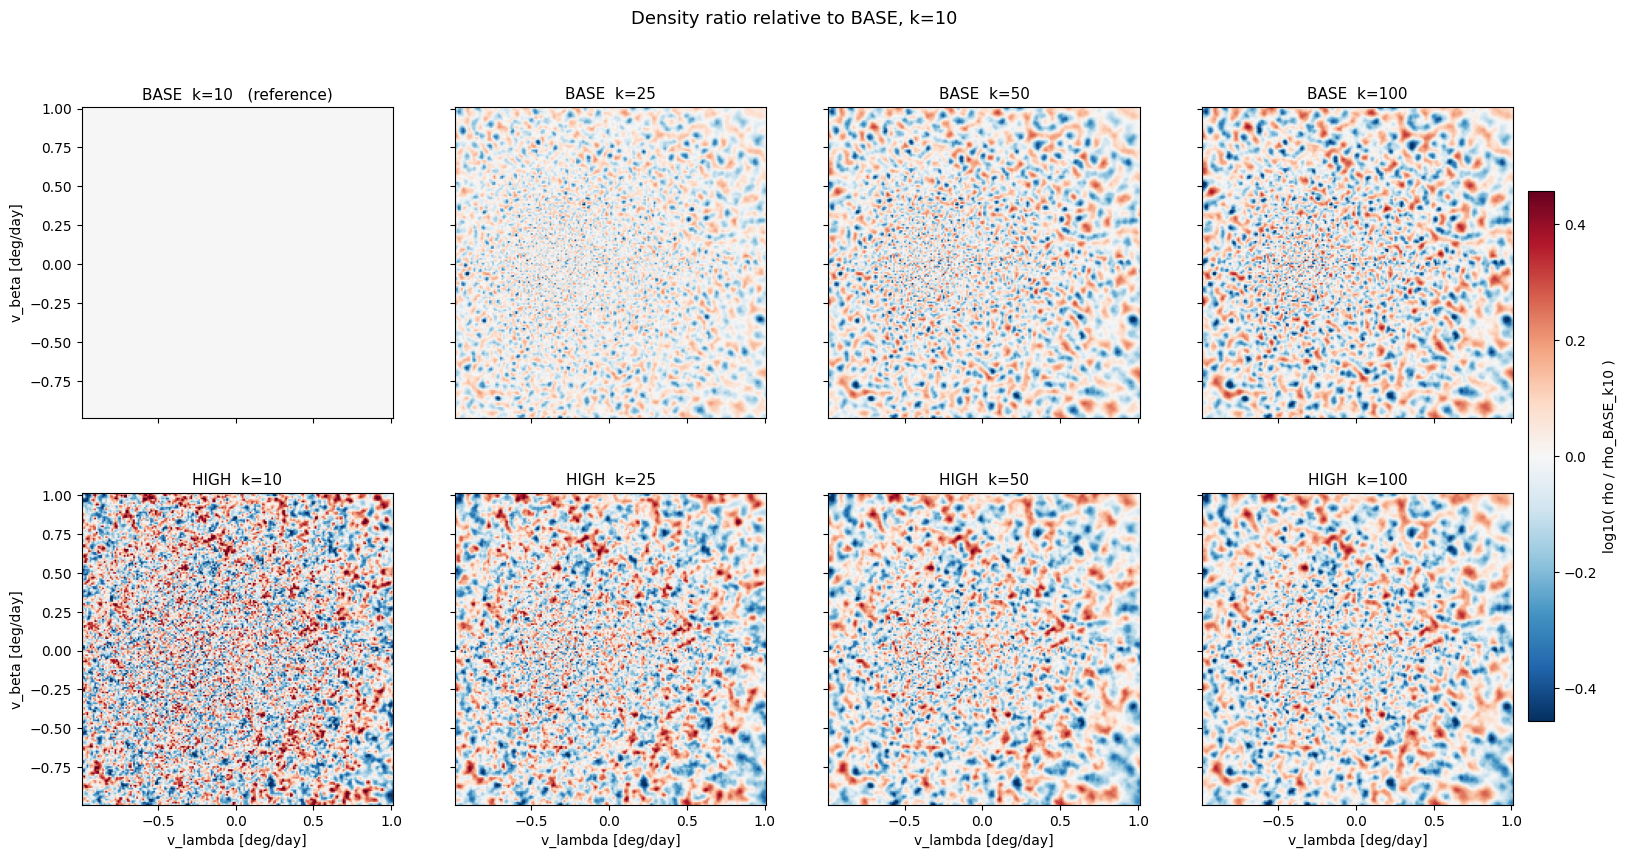

In [7]:
ref=dmap("BASE",10)
R={}
for s in SRCS:
    for k in KS:
        with np.errstate(divide="ignore",invalid="ignore"):
            r=np.log10(dmap(s,k)/ref)
        R[(s,k)]=np.where(np.isfinite(r),r,np.nan)
lim=float(np.nanpercentile(np.abs(np.concatenate([v.ravel() for v in R.values()])),99.5))
lim=max(lim,1e-6)
print(f"symmetric colour limit: +/- {lim:.3f} dex  (99.5th percentile of |log10 ratio|)")
fig,ax=plt.subplots(2,4,figsize=(19,9.2),sharex=True,sharey=True)
for r_,s in enumerate(SRCS):
    for c,k in enumerate(KS):
        a=ax[r_,c]
        im=a.imshow(np.ma.masked_invalid(R[(s,k)]),origin="lower",extent=EXT,
                    vmin=-lim,vmax=lim,cmap="RdBu_r",aspect="equal")
        a.set_title(f"{s}  k={k}"+("   (reference)" if (s,k)==("BASE",10) else ""),fontsize=11)
        if r_==1: a.set_xlabel("v_lambda [deg/day]")
        if c==0: a.set_ylabel("v_beta [deg/day]")
fig.colorbar(im,ax=ax,fraction=0.018,pad=0.01,label="log10( rho / rho_BASE_k10 )")
fig.suptitle("Density ratio relative to BASE, k=10",fontsize=13)
plt.show()

## 7. One-dimensional density slices through v_beta = 0

slice row j=500, v_beta=-0.0000 deg/day


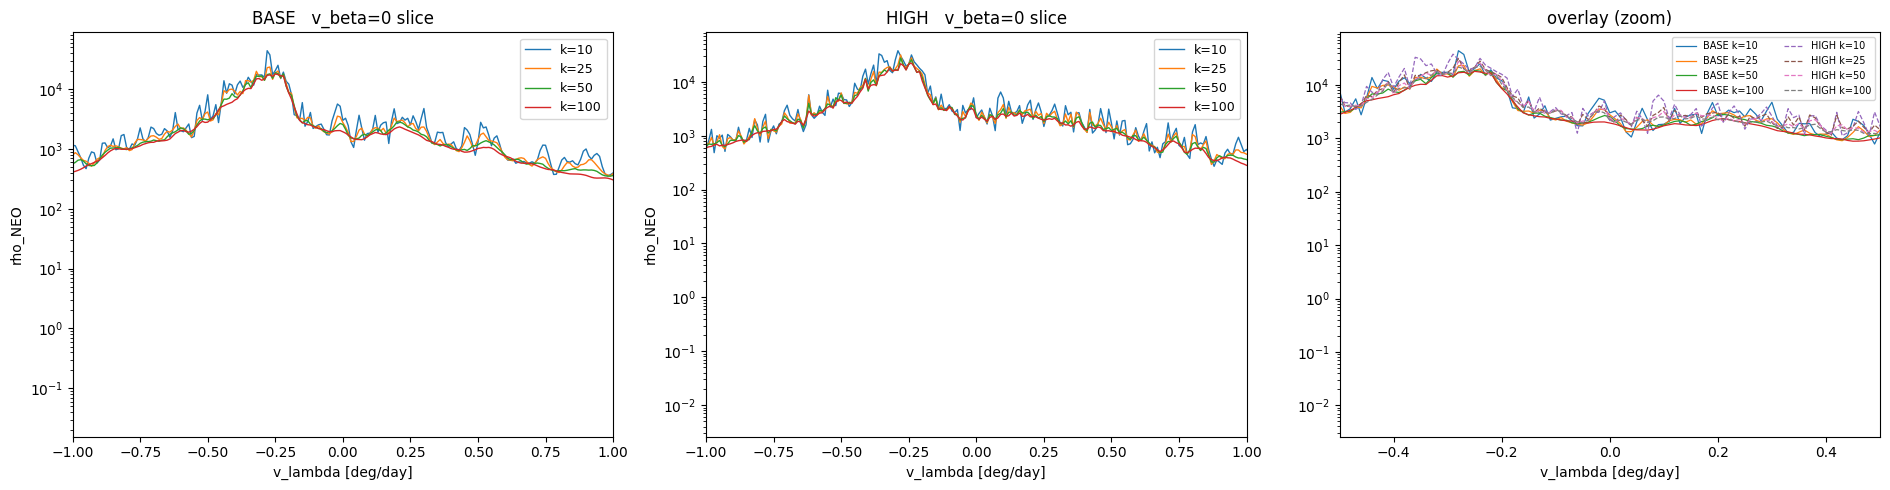

In [8]:
jz=int(np.argmin(np.abs(yg)))
print(f"slice row j={jz}, v_beta={yg[jz]:.4f} deg/day")
fig,ax=plt.subplots(1,3,figsize=(19,5.0))
for i,s in enumerate(SRCS):
    for k in KS:
        ax[i].plot(xg,np.asarray(dens[(s,k)]["density_neo_physical"],float)[jz,:],lw=1.0,label=f"k={k}")
    ax[i].set_yscale("log"); ax[i].set_xlim(-1,1); ax[i].set_title(f"{s}   v_beta=0 slice")
    ax[i].set_xlabel("v_lambda [deg/day]"); ax[i].set_ylabel("rho_NEO"); ax[i].legend(fontsize=9)
for s,ls in zip(SRCS,("-","--")):
    for k in KS:
        ax[2].plot(xg,np.asarray(dens[(s,k)]["density_neo_physical"],float)[jz,:],ls,lw=0.9,
                   label=f"{s} k={k}")
ax[2].set_yscale("log"); ax[2].set_xlim(-0.5,0.5); ax[2].set_title("overlay (zoom)")
ax[2].set_xlabel("v_lambda [deg/day]"); ax[2].legend(fontsize=7,ncol=2)
plt.tight_layout(); plt.show()

## 8. k-th neighbour distance quantiles

Distance from every grid node to its k-th nearest source point, in deg/day. `central` restricts to
the [-1, +1] window; the pixel size is 0.01 deg/day, shown for scale.

In [9]:
qr=[]
for s in SRCS:
    for k in KS:
        z=dens[(s,k)]
        f=np.asarray(z["dk_quantiles_full_grid"],float); c=np.asarray(z["dk_quantiles_central_1deg"],float)
        qr.append(dict(source=s,k=k,n_rows=int(z["n_source_rows"]),
                       full_p10=f[0],full_p50=f[1],full_p90=f[2],full_p99=f[3],
                       cen_p10=c[0],cen_p50=c[1],cen_p90=c[2],cen_p99=c[3],
                       cen_p50_px=c[1]/float(z["grid_step"])))
q=pd.DataFrame(qr)
print("pixel size = 0.01 deg/day;  cen_p50_px = median central d_k in pixels\n")
print(q.to_string(index=False,float_format=lambda v:f"{v:,.4f}"))

pixel size = 0.01 deg/day;  cen_p50_px = median central d_k in pixels

source   k  n_rows  full_p10  full_p50  full_p90  full_p99  cen_p10  cen_p50  cen_p90  cen_p99  cen_p50_px
  BASE  10   27781    0.0904    0.6921    2.3981    3.5530   0.0169   0.0310   0.0514   0.0745      3.0976
  BASE  25   27781    0.1449    0.9855    2.7217    3.8899   0.0279   0.0500   0.0796   0.1156      5.0000
  BASE  50   27781    0.2059    1.2516    2.9724    4.1212   0.0399   0.0715   0.1126   0.1609      7.1484
  BASE 100   27781    0.2915    1.5439    3.2399    4.3884   0.0566   0.1011   0.1587   0.2231     10.1072
  HIGH  10  207059    0.0331    0.2820    1.8493    2.9246   0.0062   0.0113   0.0190   0.0279      1.1330
  HIGH  25  207059    0.0532    0.4405    2.0718    3.1990   0.0103   0.0183   0.0297   0.0425      1.8257
  HIGH  50  207059    0.0757    0.6014    2.2584    3.4230   0.0147   0.0260   0.0419   0.0602      2.5999
  HIGH 100  207059    0.1072    0.7951    2.4948    3.6560   0.0209   0.0

## 9. Observations for advisor discussion

_Descriptive notes only; nothing below is filled in automatically and no preferred `k` is selected._

**Sample count (BASE -> HIGH), at fixed k**
-
-

**Neighbour count (k = 10 -> 100), at fixed source**
-
-

**Combined**
-
-

**Anything that looks like an artifact rather than structure**
-
-

**Open questions**
-
-